# Beat travel times (OSRM)

Driving minutes from the center of each Oakland police beat to every address in that beat.

In [1]:
import time
import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import shapely
from box_utils import BOX_ROOT

OSRM = "https://router.project-osrm.org" # public demo server: <= 1 req/sec, max 100 coords per table call. self-host for bigger runs.
OPD  = BOX_ROOT / "OPD & TAN - Core Workspace" / "02 Oakland Police Dept (OPD)"
DATA = OPD / "Data" / "Our Data"     # inputs only
OUT  = OPD / "Outputs"              # anything we produce

In [2]:
# 1) beat polygons: https://data.oaklandca.gov/Public-Safety/Police-Beats/78s7-673i/about_data
#    59 polygons, lon/lat. "name" = beat code (e.g. "03Y"). LKM1 = Lake Merritt, PDT2 = Piedmont -> dropped.
beats_all = gpd.read_file("https://data.oaklandca.gov/api/geospatial/78s7-673i?method=export&format=GeoJSON")
beats_all = beats_all[["name", "pol_dist", "acres", "geometry"]].rename(columns={"name": "beat", "pol_dist": "area"})
enclaves = beats_all[beats_all["beat"].isin(["LKM1", "PDT2"])].assign(label=["Lake Merritt", "Piedmont"])   # not OPD beats; kept for map labels
beats = beats_all.query("beat not in ['LKM1', 'PDT2']").sort_values("beat").reset_index(drop=True)
# the source layer has 12 tiny stray polygon pieces (69 m squares, some in San Leandro) attached to 5 beats -> keep each beat's main polygon only
beats["geometry"] = beats.geometry.apply(lambda g: max(g.geoms, key=lambda p: p.area) if g.geom_type == "MultiPolygon" else g)
print(len(beats), "beats")
beats.head()

57 beats


,beat,area,acres,geometry
0,01X,1,302.94300000000004,"POLYGON ((-122.27508 37.79812, -122.27463 37.7..."
1,02X,1,612.34,"POLYGON ((-122.28216 37.79627, -122.28389 37.7..."
2,02Y,1,2092.527,"POLYGON ((-122.29152 37.81081, -122.29153 37.8..."
3,03X,1,214.241,"POLYGON ((-122.26221 37.7922, -122.26231 37.79..."
4,03Y,1,125.054,"POLYGON ((-122.27502 37.79821, -122.27508 37.7..."


In [3]:
# 2) all Oakland address points (Alameda County GIS), cached in Box by an earlier pull
#    source: https://www.arcgis.com/home/item.html?id=4610acbf49364583986d45ee4106cc3f
addresses = pd.read_parquet(DATA / "oakland_address_points.parquet")
print(len(addresses), "Oakland address points in Box cache")
addresses = gpd.GeoDataFrame(addresses, geometry=gpd.points_from_xy(addresses["lon"], addresses["lat"]), crs=4326)
addresses = gpd.sjoin(addresses, beats[["beat", "geometry"]], how="inner", predicate="within").drop(columns="index_right")
print(len(addresses), "fall inside one of the 57 beats")
addresses.head()

132144 Oakland address points in Box cache


131923 fall inside one of the 57 beats


,ADDRESS,ZIPCODE,UNIT,APN,lon,lat,geometry,beat
0,2915 Monticello Ave,94619,None,036 244200400,-122.196625,37.780706,POINT (-122.19662 37.78071),28X
1,2448 66th Ave,94605,None,039 325903600,-122.186778,37.766850,POINT (-122.18678 37.76685),30X
2,9521 Alcala Ave,94605,None,043A475000300,-122.151499,37.755634,POINT (-122.1515 37.75563),35X
3,1889 Harrison St Apt 407,94612,407,008 062506400,-122.265949,37.806104,POINT (-122.26595 37.8061),04X
4,1843 E 38th St,94602,None,023 049602200,-122.219529,37.802228,POINT (-122.21953 37.80223),16Y


In [4]:
# 3) distance from each address to its beat's boundary (kept as a column so we can split edge vs interior later)
addr_m  = addresses.to_crs(26910)                                      # meters (UTM 10N)
bound_m = beats.set_index("beat").to_crs(26910).geometry.boundary
addresses["dist_to_edge_m"] = shapely.distance(addr_m.geometry.values, bound_m.loc[addr_m["beat"]].values)
print(f"{(addresses['dist_to_edge_m'] <= 100).sum():,} of {len(addresses):,} addresses are within 100 m of a beat edge")
addresses.head()

35,283 of 131,923 addresses are within 100 m of a beat edge


,ADDRESS,ZIPCODE,UNIT,APN,lon,lat,geometry,beat,dist_to_edge_m
0,2915 Monticello Ave,94619,None,036 244200400,-122.196625,37.780706,POINT (-122.19662 37.78071),28X,359.507112
1,2448 66th Ave,94605,None,039 325903600,-122.186778,37.766850,POINT (-122.18678 37.76685),30X,24.333470
2,9521 Alcala Ave,94605,None,043A475000300,-122.151499,37.755634,POINT (-122.1515 37.75563),35X,173.594734
3,1889 Harrison St Apt 407,94612,407,008 062506400,-122.265949,37.806104,POINT (-122.26595 37.8061),04X,285.272983
4,1843 E 38th St,94602,None,023 049602200,-122.219529,37.802228,POINT (-122.21953 37.80223),16Y,146.409020


In [5]:
# 4) beat centers: centroid (falls back to a guaranteed-inside point for odd shapes). OSRM snaps it to the nearest road.
cen = beats.to_crs(26910).geometry.centroid
inside = cen.within(beats.to_crs(26910).geometry)
cen[~inside] = beats.to_crs(26910).geometry.representative_point()[~inside]
beats["center"] = cen.to_crs(4326)
beats["center_lon"] = beats["center"].x
beats["center_lat"] = beats["center"].y
beats[["beat", "center_lon", "center_lat"]].head()

,beat,center_lon,center_lat
0,01X,-122.273127,37.793888
1,02X,-122.289577,37.800513
2,02Y,-122.325203,37.804385
3,03X,-122.266758,37.798545
4,03Y,-122.276585,37.802748


In [6]:
# 5) OSRM: center -> EVERY address in the beat. Demo server caps URL length (~400 coords/call), so destinations go in chunks.
#    ~130k addresses / 350 = ~430 calls at 1 req/sec -> ~8 min. (self-hosted OSRM would do this in seconds)
CHUNK = 350

def osrm_center_to(beat, dests):
    c = beats.loc[beats["beat"] == beat].iloc[0]
    coords = ";".join([f"{c['center_lon']:.6f},{c['center_lat']:.6f}"] + [f"{lon:.6f},{lat:.6f}" for lon, lat in zip(dests["lon"], dests["lat"])])
    r = requests.get(f"{OSRM}/table/v1/driving/{coords}", params={"sources": "0", "annotations": "duration,distance"}, timeout=60)
    r.raise_for_status()
    js = r.json()
    out = dests[["beat", "ADDRESS", "lon", "lat", "dist_to_edge_m"]].copy()
    out["minutes"] = np.array(js["durations"][0][1:], dtype=float) / 60
    out["km"]      = np.array(js["distances"][0][1:], dtype=float) / 1000
    return out

RERUN_OSRM = False   # True = call OSRM again (~8-18 min on the demo server). False = load the last run saved in Box Outputs.

if RERUN_OSRM:
    results, n_calls = [], 0
    for beat in beats["beat"]:
        a = addresses[addresses["beat"] == beat]
        for start in range(0, len(a), CHUNK):
            results.append(osrm_center_to(beat, a.iloc[start:start + CHUNK]))
            n_calls += 1
            time.sleep(1.1)                   # demo-server rate limit (1 req/s)
    results = pd.concat(results, ignore_index=True)
    print(f"{len(results):,} center->address travel times from {n_calls} OSRM calls")
else:
    results = pd.read_parquet(OUT / "beat_center_to_addresses_times.parquet")
    print(f"{len(results):,} center->address travel times loaded from last run")
results.head()

131,923 center->address travel times loaded from last run


,beat,ADDRESS,lon,lat,dist_to_edge_m,minutes,km
0,01X,277 5th St,-122.271092,37.796299,28.481148,2.356667,1.3412
1,01X,568 3rd St,-122.278656,37.798104,142.463308,3.018333,1.8979
2,01X,401 Alice St,-122.270883,37.795928,57.104487,1.775000,1.1272
3,01X,311 2nd St Unit 702,-122.273373,37.794668,280.005342,2.463333,1.4327
4,01X,40 Harrison St Apt 257,-122.273159,37.793519,273.195138,5.580000,4.1410


In [7]:
# 6) per-beat summary (minutes from center to every address)
summary = (results.groupby("beat")["minutes"]
                  .agg(n="size", median="median", p90=lambda s: s.quantile(.9), max="max")
                  .round(1).reset_index()
                  .merge(beats[["beat", "area", "acres", "center_lon", "center_lat"]], on="beat"))
print("citywide: median", summary["median"].median(), "min | worst beat max", summary["max"].max(), "min")
summary.sort_values("max", ascending=False).head(10)

citywide: median 1.9 min | worst beat max 24.7 min


,beat,n,median,p90,max,area,acres,center_lon,center_lat
7,05Y,851,13.1,13.8,24.7,1,1866.395,-122.324300,37.816063
9,07X,2193,15.4,16.1,17.5,1,3284.273,-122.326542,37.827771
18,13Y,4057,7.9,10.4,15.0,2,2789.632,-122.225390,37.859502
2,02Y,1796,4.6,5.3,13.2,1,2092.527,-122.325203,37.804385
56,35Y,2629,4.6,6.9,11.3,6,2689.367,-122.133566,37.751278
39,25Y,2334,6.4,9.7,11.0,4,1924.476,-122.150274,37.786887
48,31X,143,7.4,8.7,10.0,6,13616.028,-122.224506,37.693147
50,31Z,1415,2.1,3.0,9.4,6,295.576,-122.178946,37.730686
34,22Y,3473,6.3,7.4,9.3,4,1327.376,-122.188220,37.805445
17,13X,2661,2.5,3.4,9.0,2,981.25,-122.235336,37.839146


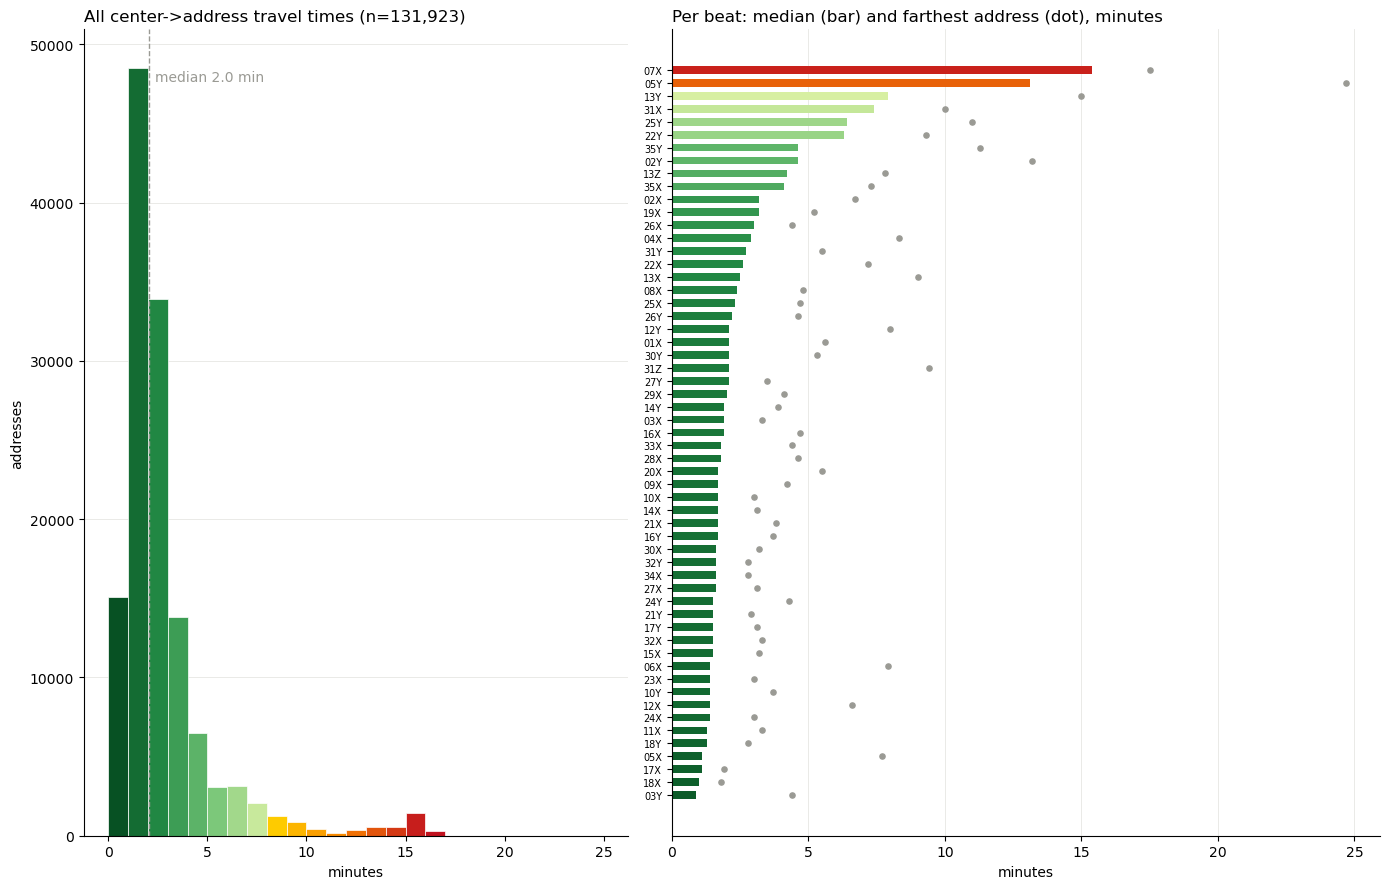

In [8]:
# 6b) distribution of travel times
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

# color scale: dark green at 0 -> light yellow-green at 8 (hard cutoff), then yellow -> orange -> red for 8-16+
from matplotlib.colors import ListedColormap
VMAX = 16
greens = LinearSegmentedColormap.from_list("g", ["#00441b", "#238b45", "#74c476", "#d9f0a3"])(np.linspace(0, 1, 128))   # 0-8 min
hots   = LinearSegmentedColormap.from_list("h", ["#ffd600", "#f77f00", "#c1121f"])(np.linspace(0, 1, 128))              # 8-16 min
CMAP = ListedColormap(np.vstack([greens, hots]), name="mins")
CMAP.set_over("#c1121f")
NORM = Normalize(vmin=0, vmax=VMAX)
GREY = "#9a9a94"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 9), gridspec_kw={"width_ratios": [1, 1.3]})

# left: all center->address times, bars colored on the same scale
bins = np.arange(0, results["minutes"].max() + 1, 1)
counts, edges_, patches = ax1.hist(results["minutes"].dropna(), bins=bins, edgecolor="white", linewidth=.5)
for p, left in zip(patches, edges_[:-1]):
    p.set_facecolor(CMAP(NORM(left + .5)))
med = results["minutes"].median()
ax1.axvline(med, color=GREY, linestyle="--", linewidth=1)
ax1.text(med + .3, ax1.get_ylim()[1] * .95, f"median {med:.1f} min", color=GREY, va="top")
ax1.set_title(f"All center->address travel times (n={results['minutes'].notna().sum():,})", loc="left")
ax1.set_xlabel("minutes"); ax1.set_ylabel("addresses")

# right: per beat, median (bar, colored by value) and farthest address (dot), sorted by median
s = summary.sort_values("median")
y = np.arange(len(s))
ax2.barh(y, s["median"], color=[CMAP(NORM(v)) for v in s["median"]], height=.6)
ax2.scatter(s["max"], y, color=GREY, s=14, zorder=3)
ax2.set_yticks(y); ax2.set_yticklabels(s["beat"], fontsize=7)
ax2.set_title("Per beat: median (bar) and farthest address (dot), minutes", loc="left")
ax2.set_xlabel("minutes")

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x" if ax is ax2 else "y", color="#e6e6e3", linewidth=.6); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(OUT / "beat_center_to_addresses_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

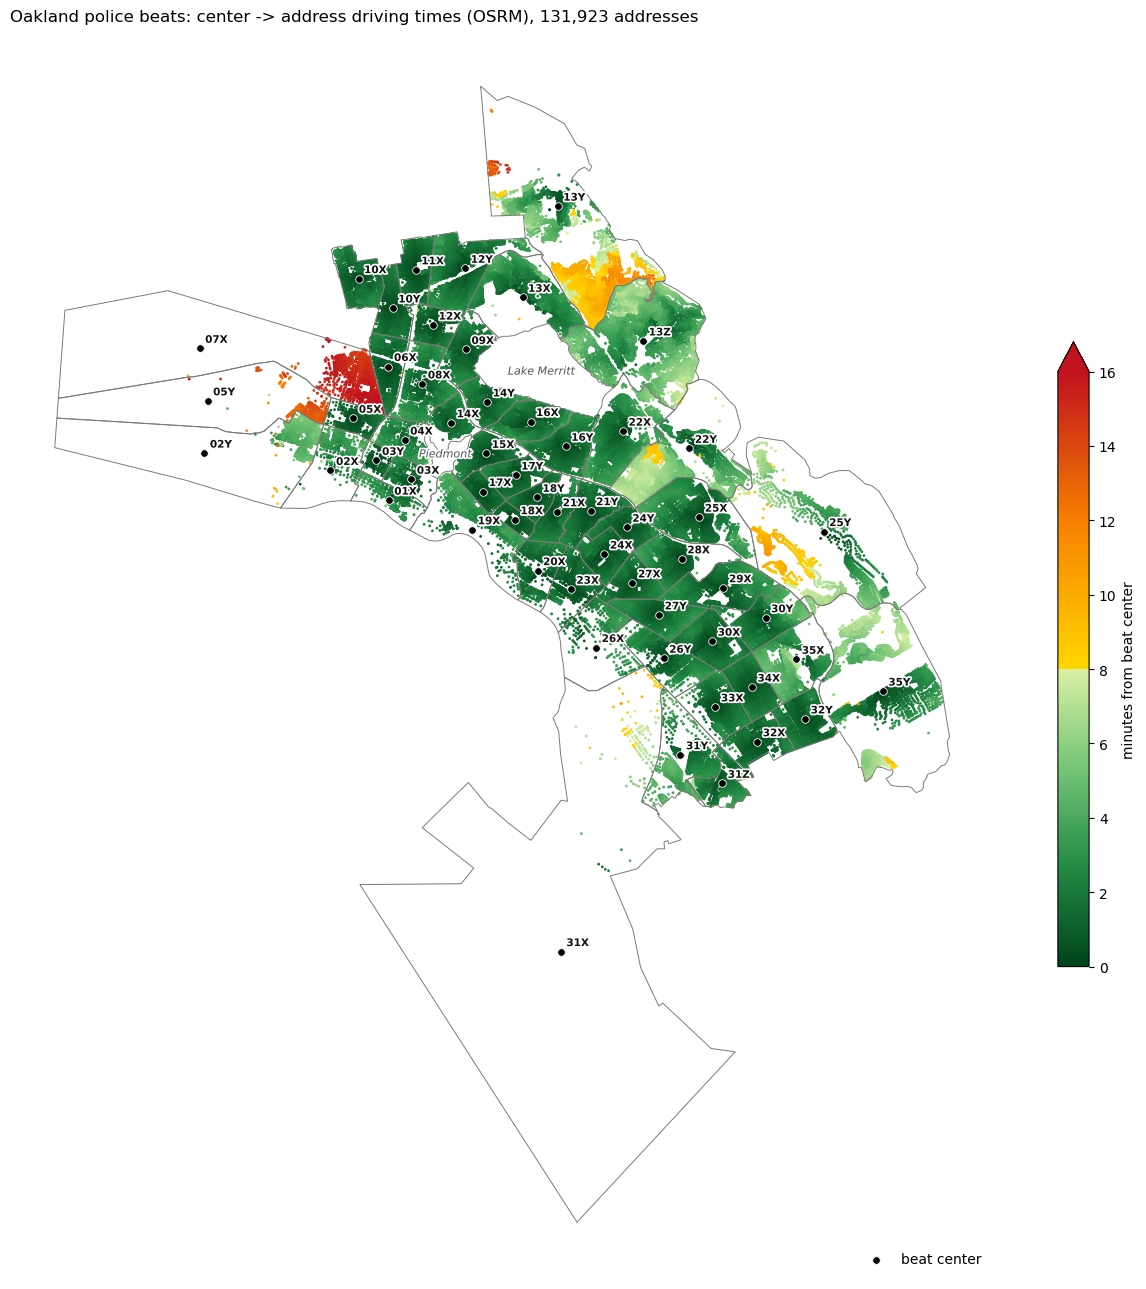

In [9]:
# 6c) map: beat outlines, every address colored by minutes from its beat center, beat centers marked
fig, ax = plt.subplots(figsize=(13, 13))
beats.boundary.plot(ax=ax, color="#7a7a75", linewidth=.7)
pts = gpd.GeoDataFrame(results, geometry=gpd.points_from_xy(results["lon"], results["lat"]), crs=4326)
pts.plot(ax=ax, column="minutes", cmap=CMAP, norm=NORM, markersize=1, legend=True,
         legend_kwds={"label": "minutes from beat center", "shrink": .5, "extend": "max"})
ax.scatter(beats["center_lon"], beats["center_lat"], color="black", edgecolor="white", linewidth=.6, s=30, zorder=5, label="beat center")
import matplotlib.patheffects as pe
halo = [pe.withStroke(linewidth=2.5, foreground="white")]           # keeps labels readable on dark green
for _, b in beats.iterrows():
    ax.annotate(b["beat"], (b["center_lon"], b["center_lat"]), xytext=(4, 4), textcoords="offset points", fontsize=7.5,
                color="#111", fontweight="bold", path_effects=halo)
for _, e in enclaves.iterrows():                       # Lake Merritt / Piedmont: not OPD beats, shown so the holes are clear
    c = e.geometry.centroid
    ax.annotate(e["label"], (c.x, c.y), ha="center", va="center", fontsize=8, color="#555", style="italic", path_effects=halo)
ax.set_title(f"Oakland police beats: center -> address driving times (OSRM), {len(pts):,} addresses", loc="left")
ax.set_aspect(1 / np.cos(np.radians(37.8)))     # keep lon/lat proportions right at Oakland's latitude
ax.set_axis_off(); ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.savefig(OUT / "beat_center_to_addresses_map.png", dpi=200, bbox_inches="tight")
plt.show()

In [10]:
# 7) save for mapping later
results.to_parquet(OUT / "beat_center_to_addresses_times.parquet", index=False)
summary.to_csv(OUT / "beat_center_to_addresses_summary.csv", index=False)
print("saved to", OUT)

saved to /Users/averylee/Library/CloudStorage/Box-Box/OPD & TAN - Core Workspace/02 Oakland Police Dept (OPD)/Outputs


In [11]:
# NOTES
# - Travel times are OSRM free-flow civilian driving (OpenStreetMap roads), not police response. Calibration idea:
#   CAD observed drive time = arrival_time - dispatch_time (harmonized_calls_2021_2026.parquet; 2026 sheet also has
#   FirstUnitEnrouteTime -> arrived - enroute is cleaner). Fit a per-beat/per-hour factor and scale OSRM minutes.
# - CAD has no unit id / unit location / coordinates -> we cannot know where the responding car actually started.
# - OPD has no live officer locations (audit p.63: patrol-car GPS installed, not activated). Beat boundaries unchanged since 2020.
# - OPD facilities if we want station origins: Police Admin Bldg 455 7th St (-122.27475, 37.79948, beat 03Y);
#   Eastmont Substation 2701 73rd Ave (-122.17543, 37.76750, beat 30Y).
# - Coordinate order: OSRM/GeoJSON = lon,lat ; Google = lat,lng. OSRM durations are seconds.